### references 
- https://www.youtube.com/watch?v=N-49t1j-XWY 
- https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

### Imports

In [104]:
import numpy as np
import pandas as pd 
import os
from data_cleaning_class import DataCleaner
from data_explorer_class import DataExplorer
import re
pd.set_option('display.max_rows', None)

### PCA

In [105]:
class PCA() : 
    def __init__(self ,X , k : int = 2):
        self.X = np.asarray(X, dtype=float)
        self.k = k 

        self.__standardize_data()
        self.__calc_eigen()


    def __standardize_data(self):
        self.mean = self.X.mean(axis = 0)
        self.std_deviation = self.X.std(axis=0)
        self.X_standardized = (self.X - self.mean) / self.std_deviation

    def __calc_eigen(self):
        self.cov_matrix = np.cov(self.X_standardized , rowvar= False)
        self.eigen_values , self.eigen_vectors = np.linalg.eigh(self.cov_matrix)

        #sorting to get PCA
        self.eigen_values = self.eigen_values[::-1]
        self.eigen_vectors = self.eigen_vectors[:, ::-1]

    def get_PCA(self):
            components = self.eigen_vectors[:, :self.k]
            X_projected = self.X_standardized @ components

            total_variance = self.eigen_values.sum()
            explained_variance_ratio = self.eigen_values[:self.k] / total_variance

            return X_projected, explained_variance_ratio


### Loading

In [106]:
script_dir = os.getcwd()
csv_path = os.path.join(script_dir , "kl.csv")
print(csv_path)

decoded_df = pd.read_csv(csv_path , encoding="cp1252")


/home/youssef/mia_ai/Task_2/Task2.2/kl.csv


### Data Exploring

=== STATISTICS ===
         Unnamed: 0             ID           Age       Overall     Potential  \
count  18207.000000   18207.000000  18206.000000  18206.000000  18207.000000   
mean    9103.000000  214298.338606     25.122048     66.237449     71.307299   
std     5256.052511   29965.244204      4.670022      6.907059      6.136496   
min        0.000000      16.000000     16.000000     46.000000     48.000000   
25%     4551.500000  200315.500000     21.000000     62.000000     67.000000   
50%     9103.000000  221759.000000     25.000000     66.000000     71.000000   
75%    13654.500000  236529.500000     28.000000     71.000000     75.000000   
99%    18023.940000  246089.940000     36.000000     83.000000     87.000000   
max    18206.000000  246620.000000     45.000000     94.000000     95.000000   

            Special  International Reputation     Weak Foot   Skill Moves  \
count  18207.000000              18159.000000  18159.000000  18159.000000   
mean    1597.809908       

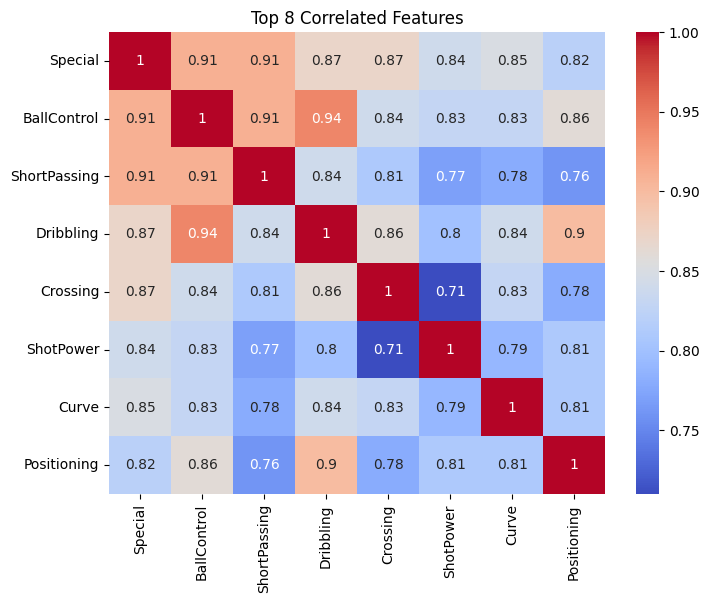

In [107]:
data_explorer = DataExplorer(csv_path) 
data_explorer.values_inspection()       #think i'll modify the class in the feature to exclude things like ID,unnamed,jersy number o.o
data_explorer.basic_structure()         #88 feature that's very high dimension relative to only 18207 sample
data_explorer.check_for_skewness()      # 
data_explorer.check_outliers()
data_explorer.get_duplicates()
data_explorer.get_correlations()        #some are very highly correlated , making them suitable for PCA
#i guess nationally can be important,since for example brazilians seems to be "talented", will look for a way to turn them into numerics for PCA , currently i'm thinking of a simple directory
#salary values should be stripped of € and turned into numerical while replacing k with 10^^3,..etc
#preferred foot can be mapped to [0,1]
# according to google Work Rate in FIFA is a two-part rating showing how actively a player moves without the ball
# i guess that's kinda important for defender so i'll map it too 
# others are already numerical so i'll keep them , i'll let the AI decide about those weird letters ones, but i'll keep as many as possible because i wanna see how PCA will determine most important factors


### Creating Numerical Dataset

In [109]:
drop_cols = ['Unnamed: 0', 'ID', 'Photo', 'Flag', 'Club Logo', 'Real Face']
players_df = decoded_df.drop(columns=drop_cols)

position_cols = ['LS','ST','RS','LW','LF','CF','RF','RW','LAM','CAM','RAM','LM',
                  'LCM','CM','RCM','RM','LWB','LDM','CDM','RDM','RWB','LB','LCB',
                  'CB','RCB','RB']

for col in position_cols :
    players_df[col] = players_df[col].str.split("+" , expand= True).astype(float).sum(axis= 1)

# print (players_df[["LS" , "ST"]].head(10))

currency_cols = ['Value', 'Wage', 'Release Clause']
def parse_currency(val):
    val = str(val).replace('€', '').strip()
    multiplier = 1
    
    if val.endswith('M'):
        multiplier = 1_000_000
        val = val[:-1]
    elif val.endswith('K'):
        multiplier = 1_000
        val = val[:-1]
    try:
        return float(val) * multiplier
    except ValueError:
        return np.nan

for col in currency_cols:
    players_df[col] = players_df[col].apply(parse_currency)


# print(players_df[currency_cols].head(5))

def parse_height(val):
    if pd.isna(val):
        return np.nan

    val= str(val).split("'")
    val = [float(value) for value in val]
    val_inch = val[0] * 12 + val[1]
    val_cm   = val_inch * 2.54           #guess it doesn't matter since normalization is done anyway

    return float(val_cm)

players_df["Height"] =players_df["Height"].apply(parse_height)


def parse_weight(val) :
    if pd.isna(val) :
        return np.nan

    val = val.strip("lbs")
    return float(val)

players_df["Weight"] = players_df["Weight"].apply(parse_weight)




### Cleaning

In [ ]:
players_df = DataCleaner(players_df).clean_df()